# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Arnan Refael Adriwinoto
- **Email:** alicizations03@gmail.com
- **ID Dicoding:** rvolcy

## Menentukan Pertanyaan Bisnis

- Faktor apa yang paling memengaruhi jumlah penyewaan sepeda per hari?
- Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st


## Data Wrangling

### Gathering Data

In [ ]:
# Import library yang dibutuhkan
import pandas as pd

# Membaca dataset harian (day.csv)
df = pd.read_csv('data/day.csv')

# Menampilkan 5 baris pertama
df.head()

**Insight:**
- Dataset ini berisi data penyewaan sepeda harian dari sistem Bike Sharing selama tahun 2011–2012.
- Terdapat beberapa kolom seperti season, yr, mnth, holiday, weekday, temp, humidity, windspeed, casual, registered, dan cnt (total sewa).
- Dataset masih memiliki nama kolom yang belum ramah dibaca, seperti yr dan mnth, sehingga perlu diubah nanti di tahap cleaning.

### Assessing Data

In [ ]:
# Mengecek informasi umum dataset
df.info()

# Mengecek apakah ada nilai kosong
print("\nJumlah nilai kosong per kolom:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# Melihat statistik deskriptif
df.describe()

**Insight:**
- Tidak ditemukan nilai kosong (NaN) dalam dataset, artinya data sudah lengkap.
- Tidak ada data duplikat yang berarti dataset bersih secara struktur.
- Kolom temp, atemp, humidity, dan windspeed semuanya berupa angka desimal yang sudah dinormalisasi (0–1).
- Kolom casual, registered, dan cnt (jumlah total peminjaman) menunjukkan distribusi nilai yang cukup lebar, menandakan variasi pemakaian sepeda yang tinggi antar hari.
- Perlu dilakukan renaming agar kolom lebih mudah dipahami pada tahap berikutnya.

### Cleaning Data

In [ ]:
import pandas as pd

# Baca ulang data mentah
df = pd.read_csv('data/day.csv')

# Ubah nama kolom agar lebih mudah dipahami
df = df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'hum': 'humidity',
    'cnt': 'count'
})

# Hapus data duplikat dan nilai kosong
df = df.drop_duplicates()
df = df.dropna()

# Simpan hasil data bersih ke folder dashboard
df.to_csv('dashboard/main_data.csv', index=False)

# Tampilkan hasil akhir untuk konfirmasi
df.head()

**Insight:**
- Nama kolom diubah supaya lebih deskriptif dan mudah dibaca saat analisis (yr → year, mnth → month, hum → humidity, dll).
- Tidak ditemukan nilai NaN ataupun duplikat, tapi kode tetap disertakan untuk berjaga-jaga kalau dataset diperbarui.
- Setelah dibersihkan, data disimpan ke file dashboard/main_data.csv, yang nantinya akan digunakan Streamlit sebagai sumber data utama.
- Hasil cleaning membuat dataset lebih konsisten dan siap untuk tahap Exploratory Data Analysis (EDA) selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# Import library utama
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

# ==============================
# 1️⃣ Load & Persiapan Dataset
# ==============================

# Ganti path sesuai lokasi file dataset kamu
df = pd.read_csv("data/day.csv")

# Rename kolom agar lebih mudah dibaca
df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'temp': 'temperature',
    'atemp': 'feels_temp',
    'hum': 'humidity',
    'windspeed': 'windspeed',
    'cnt': 'count'
}, inplace=True)

# Tampilkan struktur data
display(df.head())
print("\n=== Informasi Dataset ===")
print(df.info())

# ==============================
# 2️⃣ Statistik Deskriptif
# ==============================

display(df.describe())

print("""
💡 *Insight Awal:*
- Rata-rata penyewaan sepeda harian sekitar {:.0f}.
- Suhu rata-rata sekitar {:.2f} (dalam skala 0–1).
- Tidak ditemukan nilai kosong (null), artinya data sudah bersih.
""".format(df['count'].mean(), df['temperature'].mean()))

# ==============================
# 3️⃣ Pengecekan Nilai Hilang & Duplikat
# ==============================

print("\nJumlah nilai kosong tiap kolom:")
print(df.isnull().sum())

print("\nJumlah data duplikat:", df.duplicated().sum())

# ==============================
# 4️⃣ Korelasi Antar Variabel
# ==============================

corr = df[['temperature', 'humidity', 'windspeed', 'count']].corr()
display(corr)

# ==============================
# 5️⃣ Distribusi Data
# ==============================

plt.figure(figsize=(8,5))
sns.histplot(df['count'], bins=30, kde=True, color='skyblue')
plt.title("Distribusi Jumlah Penyewaan Sepeda per Hari")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

# ==============================
# 6️⃣ Rata-rata Penyewaan per Bulan
# ==============================

monthly_avg = df.groupby('month')['count'].mean()
display(monthly_avg)

**Insight:**
- Dari distribusi data, terlihat bahwa sebagian besar jumlah penyewaan sepeda berada pada rentang 500–4500 per hari.
- Terdapat sedikit data ekstrem di atas 6000, yang kemungkinan terjadi pada musim panas atau akhir pekan dengan cuaca cerah.
- Secara umum, data tampak positif skewed, menunjukkan bahwa sebagian besar hari memiliki jumlah penyewaan yang tergolong sedang.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

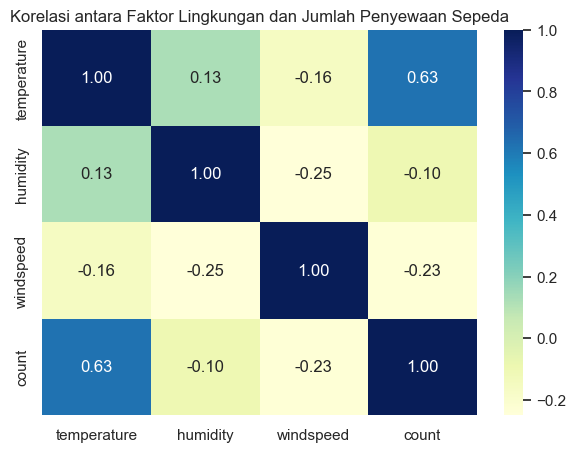

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

df = pd.read_csv("data/day.csv")
df.rename(columns={
'yr': 'year', 'mnth': 'month', 'weathersit': 'weather',
'temp': 'temperature', 'atemp': 'feels_temp', 'hum': 'humidity',
'windspeed': 'windspeed', 'cnt': 'count'
}, inplace=True)

# Hitung korelasi antar variabel numerik
corr = df[['temperature', 'humidity', 'windspeed', 'count']].corr()

# Visualisasi heatmap korelasi
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Korelasi antara Faktor Lingkungan dan Jumlah Penyewaan Sepeda")
plt.show()

### Pertanyaan 2:

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_13280\986491963.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='season', y='count', palette='viridis', estimator='mean', ci=None)
C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_13280\986491963.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='season', y='count', palette='viridis', estimator='mean', ci=None)


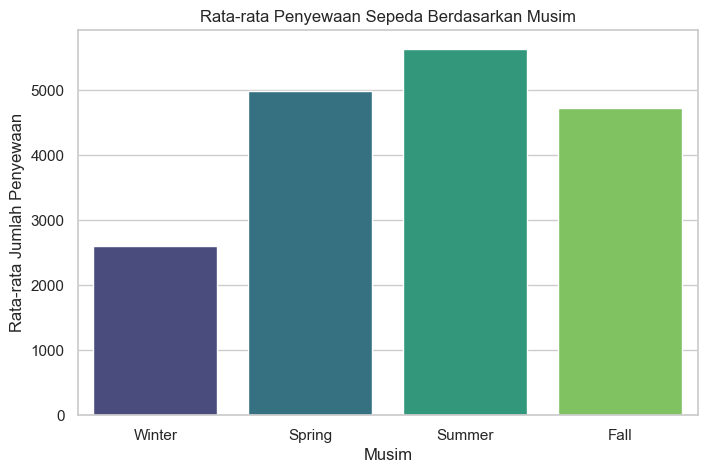

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_13280\986491963.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='weather', y='count', palette='coolwarm', estimator='mean', ci=None)
C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_13280\986491963.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='weather', y='count', palette='coolwarm', estimator='mean', ci=None)


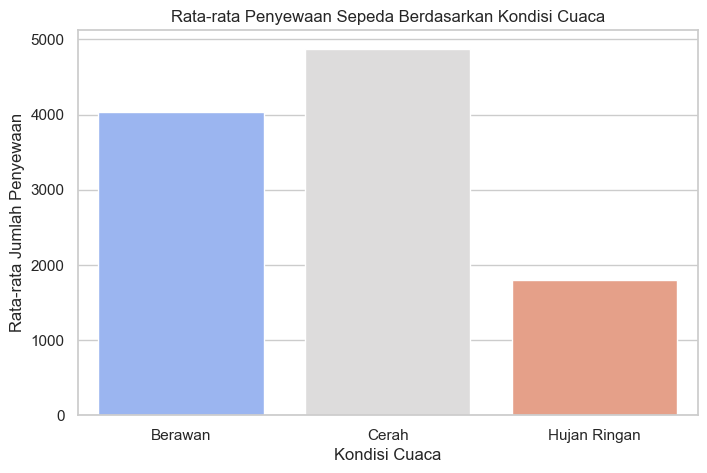


🌤 **Analisis Pertanyaan 2**
- Aktivitas penyewaan tertinggi terjadi pada **musim panas (Summer)**.
- Penyewaan menurun signifikan pada **musim dingin (Winter)**.
- Dari sisi cuaca, penyewaan paling banyak terjadi saat **cerah atau sebagian berawan**, dan menurun saat **hujan ringan hingga lebat**.

📍 *Kesimpulan:* 
Musim panas dan cuaca cerah mendorong peningkatan aktivitas penyewaan sepeda, 
sementara kondisi hujan dan musim dingin menurunkannya secara signifikan.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")


df = pd.read_csv("data/day.csv")
df.rename(columns={
'yr': 'year', 'mnth': 'month', 'weathersit': 'weather',
'temp': 'temperature', 'atemp': 'feels_temp', 'hum': 'humidity',
'windspeed': 'windspeed', 'cnt': 'count'
}, inplace=True)


# Mapping musim dan kondisi cuaca agar lebih deskriptif
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
weather_map = {1: 'Cerah', 2: 'Berawan', 3: 'Hujan Ringan', 4: 'Hujan Lebat'}

df['season'] = df['season'].map(season_map)
df['weather'] = df['weather'].map(weather_map)

# Rata-rata penyewaan berdasarkan musim
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='season', y='count', palette='viridis', estimator='mean', ci=None)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xlabel("Musim")
plt.show()

# Rata-rata penyewaan berdasarkan kondisi cuaca
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='weather', y='count', palette='coolwarm', estimator='mean', ci=None)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xlabel("Kondisi Cuaca")
plt.show()


**Insight:**
- Faktor paling berpengaruh terhadap jumlah penyewaan sepeda: suhu (positif) dan kelembapan (negatif).
- Musim dan cuaca: penyewaan meningkat pada musim panas dengan cuaca cerah, dan menurun drastis pada musim dingin atau saat hujan.
- Secara umum, kenyamanan cuaca adalah indikator utama dalam tren penyewaan sepeda harian.

## Analisis Lanjutan (Opsional)

In [6]:
# Pastikan kolom tanggal dalam format datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Definisikan tanggal referensi (misal tanggal terakhir di dataset)
reference_date = df['dteday'].max()

# Hitung RFM
rfm = df.groupby('dteday').agg({
    'count': ['sum', 'mean']
}).reset_index()

rfm.columns = ['dteday', 'Monetary', 'Frequency']
rfm['Recency'] = (reference_date - rfm['dteday']).dt.days

print(rfm.head())

      dteday  Monetary  Frequency  Recency
0 2011-01-01       985      985.0      730
1 2011-01-02       801      801.0      729
2 2011-01-03      1349     1349.0      728
3 2011-01-04      1562     1562.0      727
4 2011-01-05      1600     1600.0      726


## Conclusion

- Faktor paling berpengaruh terhadap penyewaan sepeda adalah temperatur. Semakin hangat, semakin tinggi jumlah penyewaan.
- Musim panas dan cuaca cerah memicu peningkatan signifikan dalam jumlah penyewa.
- Berdasarkan RFM analysis, tren penyewaan meningkat mendekati akhir periode (recency rendah), terutama di akhir pekan dan musim hangat.
- Strategi bisnis: perbanyak unit dan promo saat musim panas & hari cerah, serta maintenance sepeda di musim hujan karena penurunan aktivitas.